In [8]:
import numpy as np
import pandas as pd
data = pd.read_csv("sales_data_with_discounts.csv")

In [9]:
data

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [10]:
data.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [14]:
df = pd.DataFrame(data)

numerical_cols = []
categorical_cols = []

for col in df.columns:
    if df[col].dtype == 'object':       # categorical
        categorical_cols.append(col)
    else:                               # numerical
        numerical_cols.append(col)

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
Categorical Columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


In [18]:
for col in numerical_cols:
    print("Column:", col)
    print("Mean: ", df[col].mean())
    print("Median: ", df[col].median())
    print("Mode: ", df[col].mode()[0])   # mode() returns a list/Series
    print("Std: ", df[col].std())        # standard deviation
    print()

Column: Volume
Mean:  5.066666666666666
Median:  4.0
Mode:  3
Std:  4.231602391213926

Column: Avg Price
Mean:  10453.433333333332
Median:  1450.0
Mode:  400
Std:  18079.90483993645

Column: Total Sales Value
Mean:  33812.83555555555
Median:  5700.0
Mode:  24300
Std:  50535.07417255328

Column: Discount Rate (%)
Mean:  15.155241895330914
Median:  16.57776564929597
Mode:  5.007822189204133
Std:  4.220602153325511

Column: Discount Amount
Mean:  3346.499424342415
Median:  988.9337332382784
Mode:  69.17794228822787
Std:  4509.9029633539985

Column: Net Sales Value
Mean:  30466.336131270138
Median:  4677.788059301853
Mode:  326.97480055470817
Std:  46358.656624066934



<Axes: >

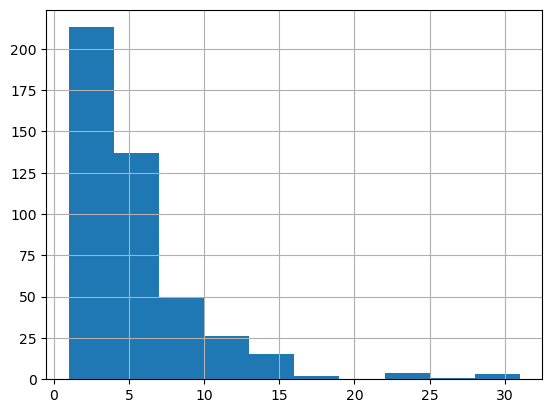

In [19]:
#histogram
df["Volume"].hist()

<Axes: >

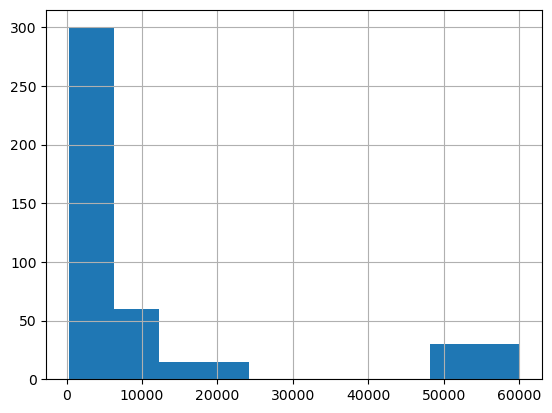

In [20]:
df["Avg Price"].hist()

<Axes: >

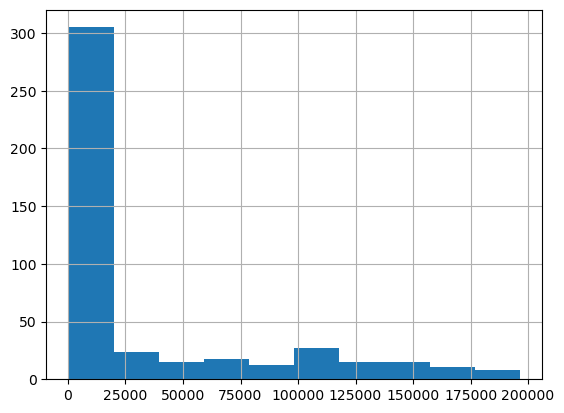

In [21]:
df["Total Sales Value"].hist()

<Axes: >

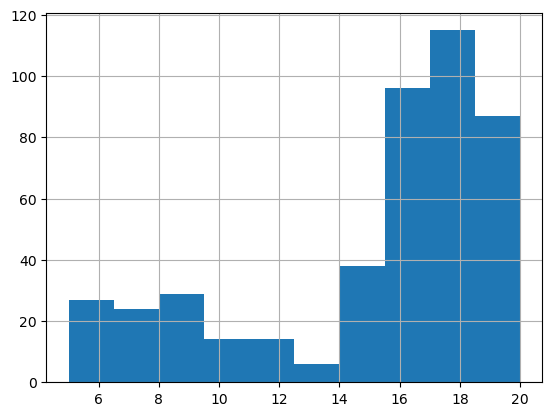

In [24]:
df["Discount Rate (%)"].hist()

<Axes: >

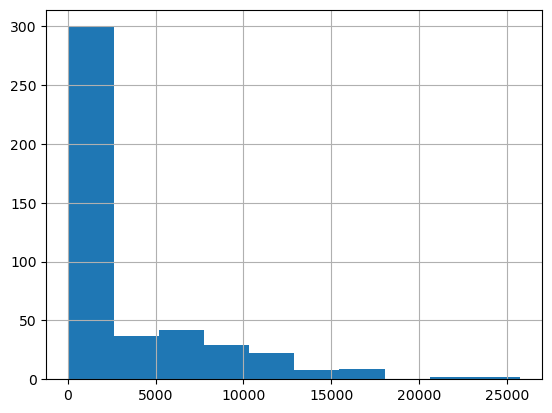

In [25]:
df["Discount Amount"].hist()

<Axes: >

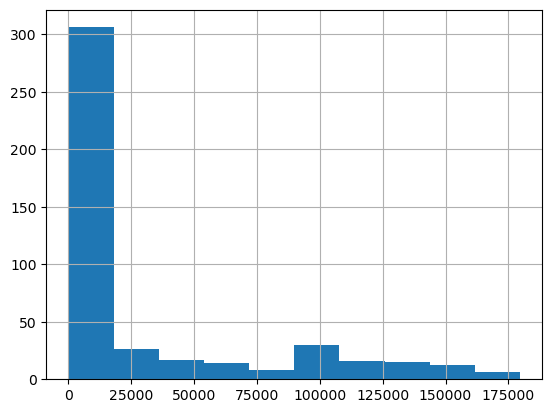

In [26]:
df["Net Sales Value"].hist()

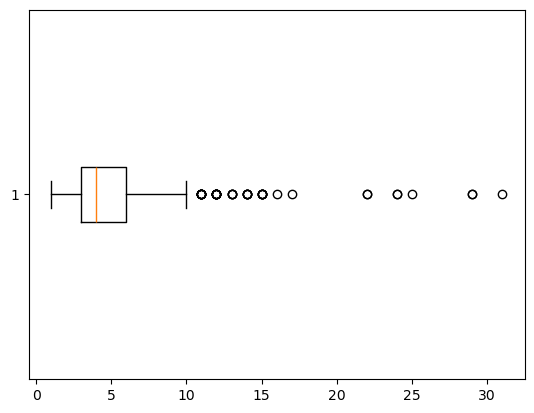

In [27]:
import matplotlib.pyplot as plt
plt.boxplot(x=df["Volume"],vert=False)
plt.show()

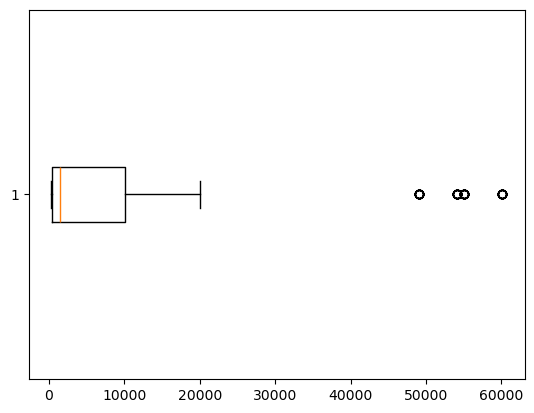

In [28]:
plt.boxplot(x=df["Avg Price"],vert=False)
plt.show()

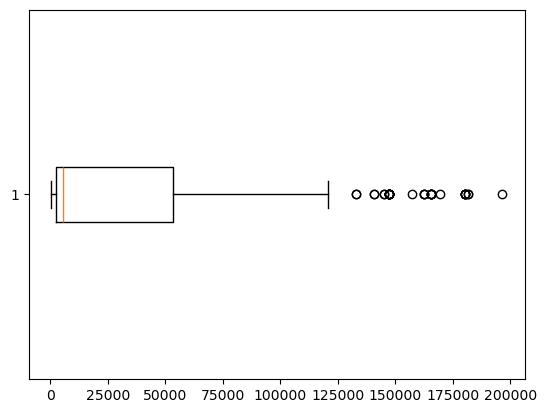

In [29]:
plt.boxplot(x=df["Total Sales Value"],vert=False)
plt.show()

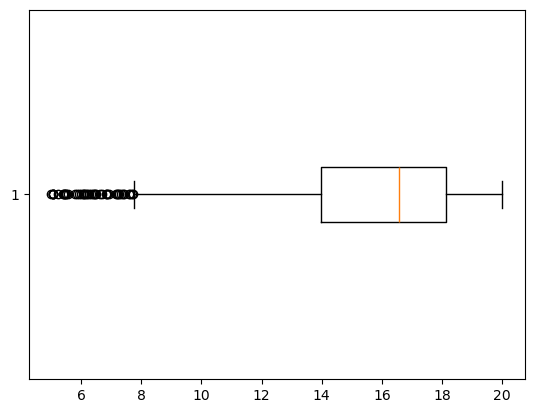

In [30]:
plt.boxplot(x=df["Discount Rate (%)"],vert=False)
plt.show()

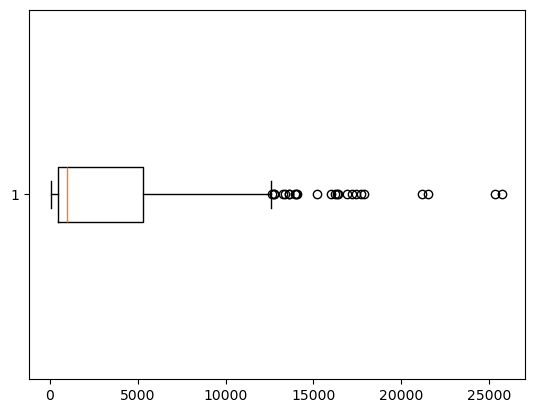

In [31]:
plt.boxplot(x=df["Discount Amount"],vert=False)
plt.show()

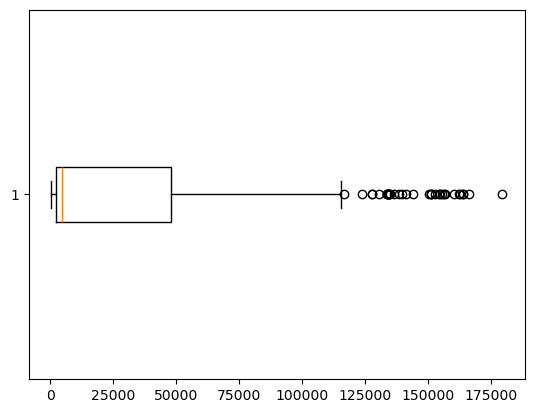

In [32]:
plt.boxplot(x=df["Net Sales Value"],vert=False)
plt.show()

In [ ]:
#Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value'
#'Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'

<Axes: xlabel='Brand'>

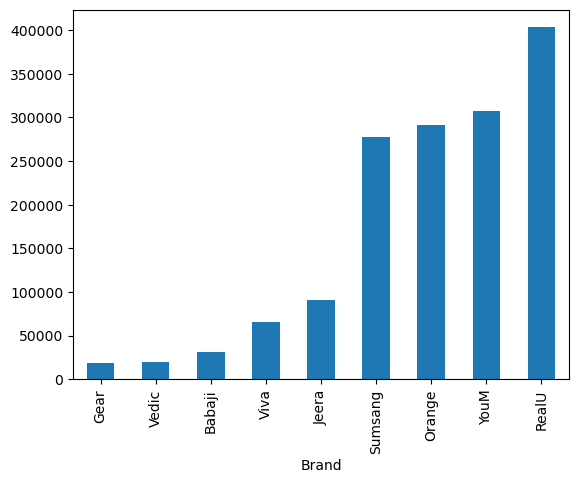

In [36]:
t2 = df.groupby("Brand")["Discount Amount"].sum().sort_values(ascending=True)
t2.plot(kind='bar')

<Axes: xlabel='Brand'>

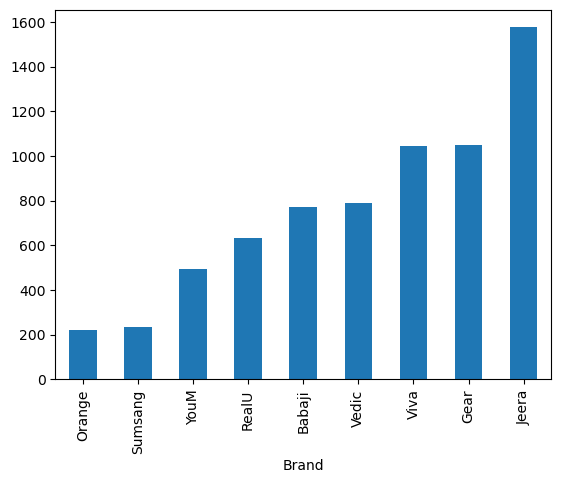

In [37]:
t2 = df.groupby("Brand")["Discount Rate (%)"].sum().sort_values(ascending=True)
t2.plot(kind='bar')

<Axes: xlabel='Brand'>

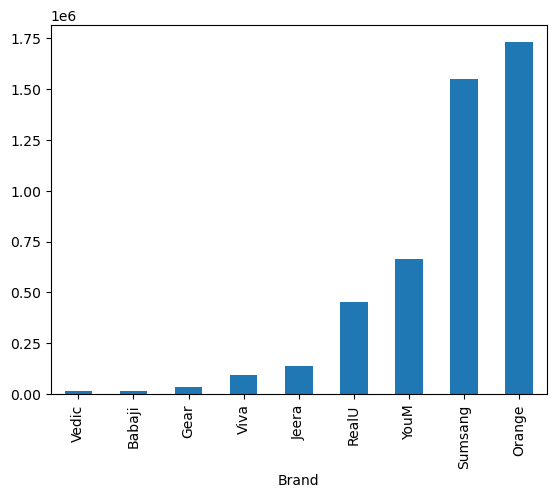

In [38]:
t2 = df.groupby("Brand")["Avg Price"].sum().sort_values(ascending=True)
t2.plot(kind='bar')

<Axes: xlabel='Brand'>

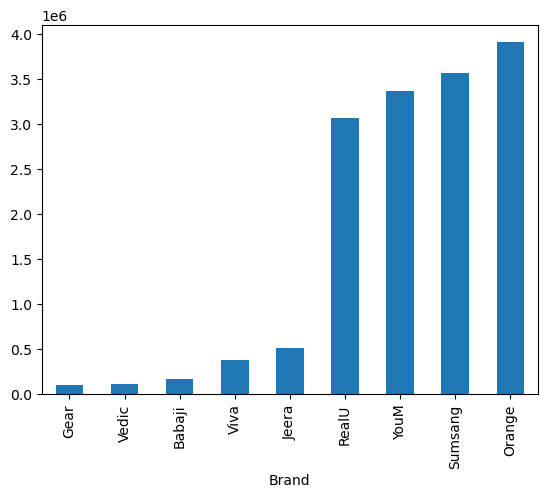

In [39]:
t2 = df.groupby("Brand")["Total Sales Value"].sum().sort_values(ascending=True)
t2.plot(kind='bar')

<Axes: xlabel='Brand'>

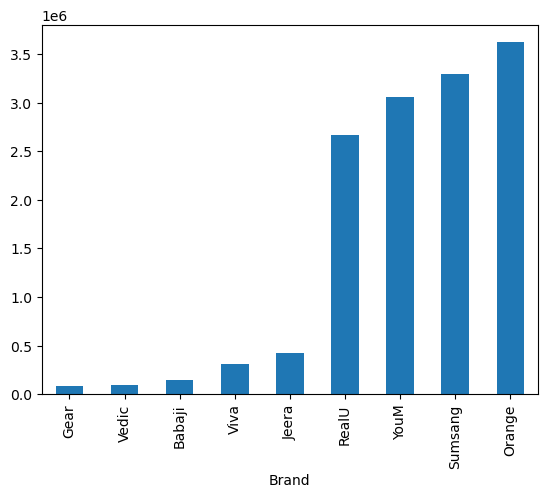

In [40]:
t2 = df.groupby("Brand")["Net Sales Value"].sum().sort_values(ascending=True)
t2.plot(kind='bar')

### Concept of Standardization (Z-score Normalization)

### Standardisation, also known as z-score normalisation, transforms the data such that:

### Mean (μ) becomes 0
### Standard deviation (σ) becomes 1

Standardization of Numerical Variables

Standardization (also known as Z-score normalization) is a data preprocessing technique used to rescale features so that they have the properties of a standard normal distribution. This is particularly important for analytical models that are sensitive to the scale of the data, such as K-Nearest Neighbors (KNN), Principal Component Analysis (PCA), and Support Vector Machines (SVM).

1. The Concept of Standardization
   
The objective is to shift the mean of each feature to 0 and scale its standard deviation to 1. This ensures that each variable contributes equally to the analysis, preventing variables with larger numerical ranges (like Total Sales Value) from dominating variables with smaller ranges (like Volume or Discount Rate).

The Formula:$$z = \frac{x - \mu}{\sigma}$$

2. Before and After ComparisonsAfter applying the formula to our dataset, we can observe that the distribution's shape remains the same, but the scale of the X-axis changes.

| Column | Original (Row 1) | Standardized (Row 1) |
| :--- | :--- | :--- |
| **Volume** | 15 | 2.347 |
| **Avg Price** | 12,100 | 0.091 |
| **Total Sales Value** | 181,500 | 2.922 |
| **Discount Rate (%)** | 11.65 | -0.829 |
| **Discount Amount** | 21,153.50 | 3.948 |
| **Net Sales Value** | 160,346.50 | 2.801 |

### Conversion of Categorical Data into Dummy Variables

The Need for Dummy Variables (One-Hot Encoding)

Most Machine Learning algorithms (such as Linear Regression, SVM, and Neural Networks) are based on mathematical equations that require numerical input. They cannot inherently understand the qualitative difference between "Thursday" and "Sunday" or "Mobile" and "Electronics."

One-Hot Encoding solves this by:

Converting each unique category into a new column.

Assigning a 1 if the observation belongs to that category and a 0 otherwise.

Preventing the model from assuming a "rank" or "order" (which would happen if we used label encoding like 1, 2, 3).

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('sales_data_with_discounts.csv')

# Identify categorical columns for encoding
# We exclude 'Date', 'SKU', and 'Model' as they often have too many unique values for basic one-hot encoding
categorical_cols = ['Day', 'City', 'BU', 'Brand']

# Apply One-Hot Encoding (Dummy Variables)
df_dummies = pd.get_dummies(df, columns=categorical_cols)

# Display the first 5 rows of the newly created dummy columns
# We use .filter to show just a portion of the transformed data for clarity
df_dummies.filter(regex='Day_|City_|BU_|Brand_').head()

,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,City_C,BU_FMCG,BU_Lifestyle,BU_Mobiles,Brand_Babaji,Brand_Gear,Brand_Jeera,Brand_Orange,Brand_RealU,Brand_Sumsang,Brand_Vedic,Brand_Viva,Brand_YouM
0,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False
1,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False
2,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True
3,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True
4,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True


### Conclusion

1. Summary of Key Findings.

Based on the descriptive analytics and visualizations of the sales dataset, several critical insights emerged:

Brand Performance: The brand "Orange" emerged as the top performer in terms of Total Sales Value, indicating a strong market presence or higher unit pricing.

Regional Trends: City C recorded the highest sales Volume, marking it as a key geographical hub for high-frequency transactions.

Discount Effectiveness: The Average Discount Rate was approximately 15.16%. Interestingly, the correlation between discount rates and volume sold was relatively low ($0.158$), suggesting that while discounts help move products, they are not the sole factor driving massive volume spikes.

Pricing Strategy: There is a significant variance in Avg Price (ranging from $290$ to $60,100$), suggesting a diverse product portfolio catering to both budget and premium segments.

2. Reflection on Preprocessing

Data preprocessing is the bridge between raw, messy data and high-performance machine learning models.

Importance of Standardization (Z-score Scaling):

In our dataset, variables like Avg Price and Volume exist on completely different scales (thousands vs. single digits). If fed directly into an algorithm like K-Means or Linear Regression, the model would incorrectly assume that Avg Price is more important simply because its numerical values are larger. Standardization ensures every feature contributes equally, allowing the model to learn based on the variance of the data rather than its magnitude.

Importance of One-Hot Encoding:

Machine learning models are essentially mathematical equations that cannot "read" words like "Mobiles" or "Thursday." Converting these into Dummy Variables (binary 0s and 1s) translates human-readable categories into a mathematical format. This prevents the model from assigning an artificial "rank" (e.g., assuming Friday is "better" than Monday just because it might be assigned a higher integer), thereby preserving the integrity of categorical relationships.